In [1]:
#  Load data and set up analysis switches
from pathlib import Path
import fusiproc_utils2 as fu
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting, image
from nilearn.signal import clean
from typing import List, Optional, Sequence, Tuple, Union


# -------- dataset paths -------
BASE = Path('/Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003/EV_Claire')
RUN  = 'sub-Forest001_ses-20260120_task-audio_run-003_pwd.nii.gz'
PWD  = BASE / RUN
SIDE = BASE / RUN.replace('_pwd.nii.gz', '_pwd.json')

# -------- analysis switches ----
CONF_USE = dict(
    motion_fsl24  = True,    # Friston24 (mutually exclusive with motion_6)
)

# --- temporal smoothing ------------------------------------------------------
SMOOTH_METHOD  = "none"          # {"none", "boxcar", "savgol"}
SMOOTH_WINDOW  = 3                 # if smoothing with boxcar (odd)

FD_THRESH     = 0.5          # mm
RADIUS_MM     = 50.0         # mm for FD sphere

# ---------------------------------------------------------------------------
# Build a short suffix that encodes the chosen method (+ key params)
# ---------------------------------------------------------------------------
if SMOOTH_METHOD == "none":
    smooth_tag = "_nosmooth"

elif SMOOTH_METHOD == "boxcar":
    smooth_tag = f"_boxcar{SMOOTH_WINDOW}"


def detect_motion_via_global(
        sig: np.ndarray, t_r: float, k: float = 3.0,
        high_pass: float = 0.01,
        y_lim: Optional[Tuple[float, float]] = None,
        frame_indices: Optional[np.ndarray] = None
) -> tuple[np.ndarray, np.ndarray, plt.Figure]:
    # High-pass filter (+ detrend) to remove slow drifts before thresholding
    sig_filt = clean(sig.reshape(-1, 1), detrend=True, high_pass=high_pass,
                     standardize=False, t_r=t_r).ravel()
    med = np.median(sig_filt)
    mad = np.median(np.abs(sig_filt - med))
    thr = med + k * mad
    bad = np.where(sig_filt > thr)[0]
    good = np.array([i for i in range(sig.size) if i not in bad], dtype=np.int64)

    x = frame_indices if frame_indices is not None else np.arange(len(sig))

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Top panel: input signal with outlier markers
    axes[0].plot(x, sig)
    for f in bad:
        axes[0].axvline(x[f], ls='--', c='r', alpha=.3)
    axes[0].set_title("Global signal with motion outliers")
    axes[0].set_ylabel("Average Intensity")
    if y_lim:
        axes[0].set_ylim(y_lim[0], y_lim[1])

    # Bottom panel: high-pass filtered signal with threshold
    axes[1].plot(x, sig_filt, label='high-pass filtered')
    axes[1].axhline(thr, ls='--', c='orange', label=f'threshold (med + {k}\u00b7MAD)')
    for f in bad:
        axes[1].axvline(x[f], ls='--', c='r', alpha=.3)
    axes[1].set_title("High-pass filtered signal")
    axes[1].set_xlabel("Frame #")
    axes[1].set_ylabel("Filtered intensity")
    axes[1].legend(loc='upper right')

    fig.tight_layout()
    return bad, good, fig

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


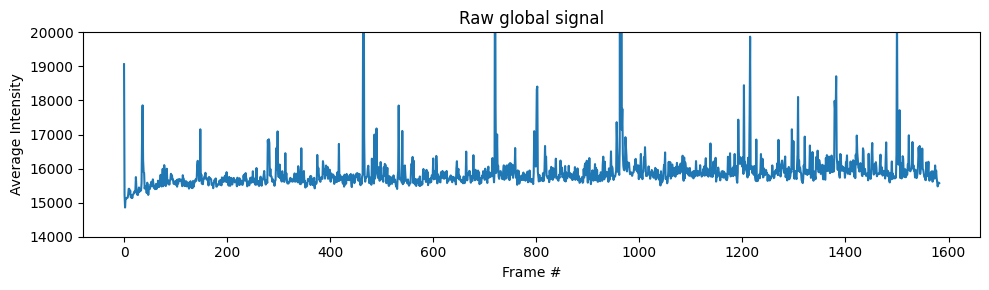

In [2]:
#  Load data and plot raw global signal
data, affine, _ = fu.load_fusi_nifti(PWD)
mask = fu.nan_mask(data)
mask_path = fu.save_nifti(mask.astype(np.uint8), affine,
                          PWD.with_name(RUN.replace('_pwd', '_mask')))

y_lim = (1.4e4, 2e4)

gs = fu.global_signal(data)
TR = fu.repetition_time(SIDE)
np.save(BASE / "t_r.npy", TR)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(gs)
ax.set_title("Raw global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")
ax.set_ylim(y_lim[0], y_lim[1])
plt.tight_layout()
plt.show()

Frames above 1.7e+04: 33
Frame indices: [   0   36  148  298  464  465  490  533  540  720  721  724  796  801
  802  956  963  964  965  966  967 1192 1203 1214 1215 1296 1308 1379
 1380 1381 1382 1500 1505]


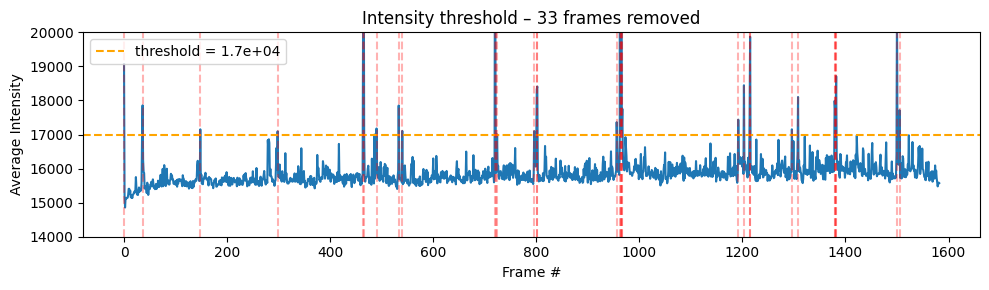

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Remove frames above an arbitrary intensity threshold
# ─────────────────────────────────────────────────────────────────────────────
INTENSITY_THRESH = 1.7e4   # <-- adjust this based on the raw plot above

bad_intensity = np.where(gs > INTENSITY_THRESH)[0]
skip = set(int(i) for i in bad_intensity)

print(f"Frames above {INTENSITY_THRESH:.1e}: {len(bad_intensity)}")
print(f"Frame indices: {bad_intensity}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(gs)
ax.axhline(INTENSITY_THRESH, ls='--', c='orange', label=f'threshold = {INTENSITY_THRESH:.1e}')
for f in bad_intensity:
    ax.axvline(f, ls='--', c='r', alpha=.3)
ax.set_title(f"Intensity threshold \u2013 {len(bad_intensity)} frames removed")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")
ax.set_ylim(y_lim[0], y_lim[1])
ax.legend()
plt.tight_layout()
plt.show()

Motion outlier frames: 154
Total skipped frames (intensity + motion): 187


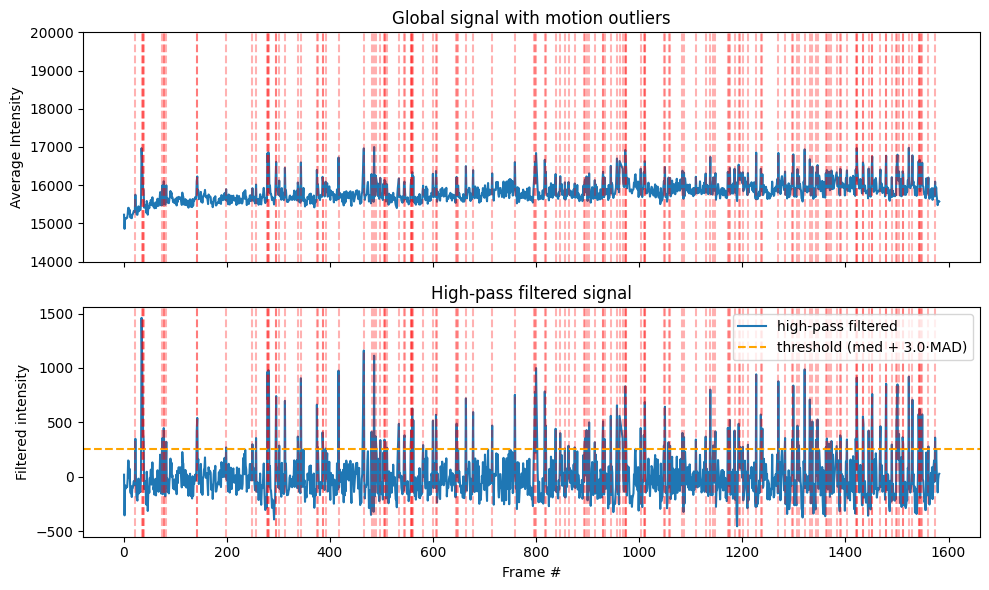

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Motion outlier detection (on signal with extreme frames removed)
# ─────────────────────────────────────────────────────────────────────────────
keep_mask = np.ones(len(gs), dtype=bool)
keep_mask[list(skip)] = False
gs_clean = gs[keep_mask]
kept_frames = np.where(keep_mask)[0]

bad_clean, good_clean, fig = detect_motion_via_global(
    gs_clean, TR, k=3.0, frame_indices=kept_frames, y_lim=y_lim)

# Map back to original frame indices
bad_gs = kept_frames[bad_clean]
skip.update(int(i) for i in bad_gs)

fig.savefig(BASE / "global_signal_with_masked_frame.png")
print(f"Motion outlier frames: {len(bad_gs)}")
print(f"Total skipped frames (intensity + motion): {len(skip)}")

In [5]:
#  Rigid registration
# ------------------------------------------------------------------
# Rigid registration
# ------------------------------------------------------------------
registration_path = BASE / "registration"

if not registration_path.exists():
    registration_path.mkdir(exist_ok=True)
    
    reg, rigid, metric, stop, kept_idx = fu.register_3d_image_stack(
            np.where(np.isfinite(data), data, 0),
            reference='median',
            spacing=np.linalg.norm(affine[:3, :3], axis=0),
            skip_indices=skip,
            mask=mask,
            verbose=True)

    # Save the registration outputs
    np.save(registration_path / "reg.npy", reg)
    np.save(registration_path / "rigid.npy", rigid)
    np.save(registration_path / "metric.npy", metric)
    np.save(registration_path / "stop.npy", stop)
    np.save(registration_path / "kept_idx.npy", kept_idx)
    np.save(registration_path / "skip.npy", skip)
    # ---- Doppler movie -------------------------------------------------
    html = fu.save_doppler_movie(reg, registration_path/"Doppler_movie_after_rigid_registration.mp4")
    html  # renders in Jupyter

else:
    reg = np.load(registration_path / "reg.npy")
    rigid = np.load(registration_path / "rigid.npy")
    metric = np.load(registration_path / "metric.npy")
    stop = np.load(registration_path / "stop.npy")
    kept_idx = np.load(registration_path / "kept_idx.npy")



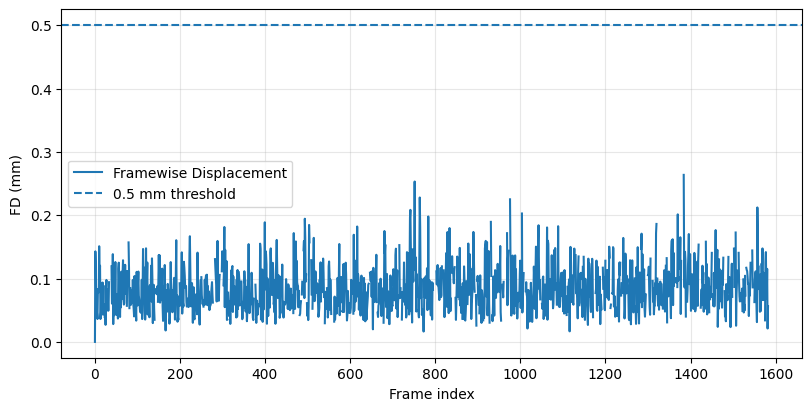

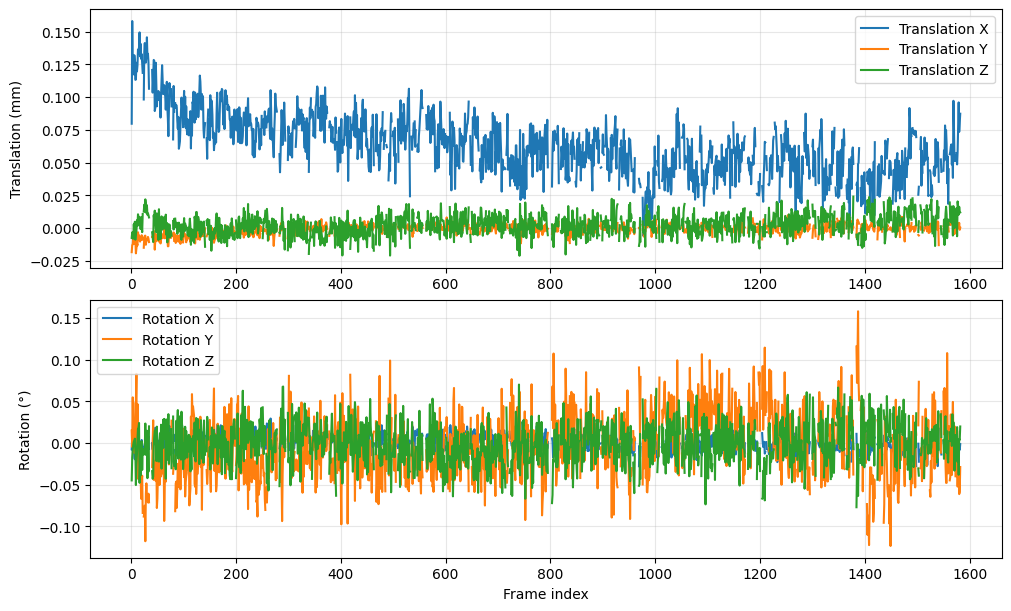

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5 – FD outliers, censor list, NaN‑padding
# ─────────────────────────────────────────────────────────────────────────────
n_frames = data.shape[-1]

# 1. FD on the gap‑free series (after GS censoring) ---------------------------
fd = fu.framewise_displacement(rigid, radius_mm=RADIUS_MM)

fd_full = np.full(n_frames, np.nan)
fd_full[kept_idx] = fd

bad_fd = fu.plot_fd(fd_full, FD_THRESH, BASE/"framewise_displacement.png")
np.savetxt(BASE/"fd_over_0p5_indices.txt", bad_fd, fmt='%d')

# 2. update global censor list ------------------------------------------------
skip.update(int(i) for i in bad_fd)

# 3. remove newly censored frames from the registration outputs ---------------
keep_after_all = [i for i in kept_idx if i not in skip]     # T indices
sel            = np.isin(kept_idx, keep_after_all)          # boolean mask

reg_use    = reg[...,  sel]           # (x,y,z,T)
rigid_use  = rigid[:,  sel]           # (6,T)
metric_use = metric[   sel]           # (T,)
stop_use   = [s for s, ok in zip(stop, sel) if ok]

# 4. create full‑length NaN‑padded arrays ------------------------------------
retained = keep_after_all                                 # same T indices
reg_full, rigid_full, metric_full, stop_full = fu.reinstate_nans(
        reg_use, rigid_use, metric_use, stop_use,
        n_frames, retained)

fu.plot_registration_parameters(rigid_full, registration_path/"registration.png")


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# sample mask, temporal smoothing, confounds (length‑matched)
# ─────────────────────────────────────────────────────────────────────────────
good_all    = np.array(retained, dtype=int)   # final list of frames to keep
sample_mask = good_all                        # passed to Nilearn

# -- temporal smoothing -------------------------------------------------------
if   SMOOTH_METHOD == "none":
    smoothed = reg_full.copy()

elif SMOOTH_METHOD == "boxcar":
    # Apply boxcar (moving average) smoothing: replaces each frame with the average across a sliding window.
    smoothed = fu.boxcar_smooth(reg_full, SMOOTH_WINDOW)


clean_img = nib.Nifti1Image(np.nan_to_num(smoothed), affine)
clean_img.to_filename(BASE/"fusi_run_clean.nii.gz")
fu.save_nifti(np.mean(clean_img.get_fdata(), axis=-1), affine, BASE/"fusi_run_clean_mean.nii.gz")

PosixPath('/Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003/EV_Claire/fusi_run_clean_mean.nii.gz')

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Voxelwise high-pass filter (cutoff = 0.01 Hz)
# ─────────────────────────────────────────────────────────────────────────────
from nilearn.signal import clean as signal_clean

fusi_data = clean_img.get_fdata()                        # (x, y, z, T)
nx, ny, nz, nt = fusi_data.shape

# Extract only retained frames (avoid filtering the zero-padded gaps)
good_data = fusi_data[..., sample_mask]                  # (x, y, z, n_good)

# Reshape to (n_good, n_voxels) – the layout nilearn.signal.clean expects
voxels_2d = good_data.reshape(-1, len(sample_mask)).T    # (n_good, n_voxels)

# High-pass filter each voxel's timeseries at 0.01 Hz
filtered_2d = signal_clean(voxels_2d, high_pass=0.01, t_r=TR, detrend=False)

# Place filtered frames back into the full-length array
filtered_data = np.zeros_like(fusi_data)
filtered_data[..., sample_mask] = filtered_2d.T.reshape(nx, ny, nz, len(sample_mask))

# Update clean_img for downstream GLM
clean_img = nib.Nifti1Image(filtered_data, affine)
clean_img.to_filename(BASE / "fusi_run_clean_highpass.nii.gz")
print(f"High-pass filtered data saved – {len(sample_mask)} retained frames, cutoff = 0.01 Hz")

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_19994/2213605038.py:16: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  filtered_2d = signal_clean(voxels_2d, high_pass=0.01, t_r=TR, detrend=False)


High-pass filtered data saved – 1396 retained frames, cutoff = 0.01 Hz


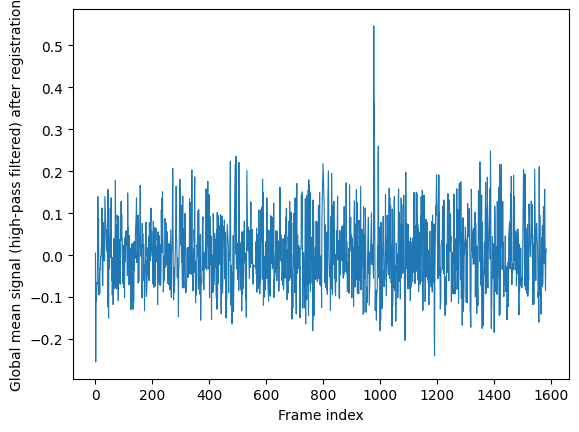

In [9]:
global_mean_filtered = np.mean(filtered_data, axis=(0,1,2))

fig, ax = plt.subplots()
ax.plot(sample_mask, global_mean_filtered[sample_mask], linewidth=0.8)
ax.set_xlabel("Frame index")
ax.set_ylabel("Global mean signal (high-pass filtered) after registration")
fig.savefig(BASE / "filtered_global_mean.png", dpi=150)
plt.show()

In [10]:
import pandas as pd
import os

if os.path.exists(BASE / 'task_events.tsv'):
    events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
else:
    task_path = list(BASE.glob('*events.tsv'))[0]
    events = pd.read_csv(task_path, sep='\t')

# events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
events["trial_type"]

0    BBC_4.mp4
1    BBC_4.mp4
2    BBC_4.mp4
3    BBC_4.mp4
4    BBC_4.mp4
5    BBC_4.mp4
Name: trial_type, dtype: object

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Explainable Variance – segment BBC epochs
# ─────────────────────────────────────────────────────────────────────────────
import json

with open(SIDE, 'r') as f:
    sidecar = json.load(f)
vol_times = np.array(sidecar["VolumeTiming"])

# Load BBC events (6 repetitions)
ev_dir = BASE 
ev_path = list(ev_dir.glob('*events.tsv'))[0]
bbc_events = pd.read_csv(ev_path, sep='\t')
print(bbc_events[['onset', 'duration', 'trial_type']].to_string())
print()

# For each BBC block, find the closest fUSI volume to the onset/offset
epochs = []
for _, row in bbc_events.iterrows():
    onset  = row['onset']
    offset = onset + row['duration']
    start_idx = np.argmin(np.abs(vol_times - onset))
    end_idx   = np.argmin(np.abs(vol_times - offset))
    epochs.append((start_idx, end_idx))
    print(f"  Onset {onset:8.1f}s → vol {start_idx:5d} (t={vol_times[start_idx]:.1f}s)  |  "
          f"Offset {offset:8.1f}s → vol {end_idx:5d} (t={vol_times[end_idx]:.1f}s)  |  "
          f"n_vols = {end_idx - start_idx}")

n_vols_per_epoch = min(end - start for start, end in epochs)
print(f"\nUsing {n_vols_per_epoch} volumes per epoch (trimmed to shortest)")

         onset  duration trial_type
0    16.185511   467.167  BBC_4.mp4
1   488.451511   467.189  BBC_4.mp4
2   960.820511   467.168  BBC_4.mp4
3  1434.218511   467.184  BBC_4.mp4
4  1907.585511   467.174  BBC_4.mp4
5  2380.199511   467.178  BBC_4.mp4

  Onset     16.2s → vol     8 (t=16.3s)  |  Offset    483.4s → vol   267 (t=483.6s)  |  n_vols = 259
  Onset    488.5s → vol   270 (t=489.0s)  |  Offset    955.6s → vol   529 (t=956.4s)  |  n_vols = 259
  Onset    960.8s → vol   531 (t=960.0s)  |  Offset   1428.0s → vol   790 (t=1427.3s)  |  n_vols = 259
  Onset   1434.2s → vol   794 (t=1434.5s)  |  Offset   1901.4s → vol  1053 (t=1902.1s)  |  n_vols = 259
  Onset   1907.6s → vol  1056 (t=1907.5s)  |  Offset   2374.8s → vol  1315 (t=2375.3s)  |  n_vols = 259
  Onset   2380.2s → vol  1318 (t=2380.7s)  |  Offset   2847.4s → vol  1576 (t=2847.0s)  |  n_vols = 258

Using 258 volumes per epoch (trimmed to shortest)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Explainable Variance 
# ─────────────────────────────────────────────────────────────────────────────
nx, ny, nz, nt = reg_full.shape

# 1. Voxel mask: voxels that are ALWAYS inside the FOV across all retained frames
#    (border voxels that move in/out during registration are excluded)
retained_data = reg_full[..., sample_mask]
voxel_mask = np.all(np.isfinite(retained_data), axis=-1)   # (nx, ny, nz)
valid_idx  = np.where(voxel_mask.ravel())[0]
n_valid    = len(valid_idx)
print(f"Valid voxels (always inside FOV): {n_valid} / {nx*ny*nz}")

# 2. Extract epochs – only valid voxels (memory efficient)
N_rep = len(epochs)
Y = np.empty((N_rep, n_vols_per_epoch, n_valid))
for i, (start, _) in enumerate(epochs):
    epoch_data = reg_full[..., start:start + n_vols_per_epoch]   # (nx,ny,nz,n_vols)
    Y[i] = epoch_data.reshape(-1, n_vols_per_epoch)[valid_idx].T # (n_vols, n_valid)

# 3. Valid timepoints: not a skipped frame in ANY of the 6 task repeats
time_valid = np.all(np.isfinite(Y), axis=(0, 2))   # (n_vols_per_epoch,)
Y_ev = Y[:, time_valid, :]                          # (N_rep, T_valid, V)
print(f"Valid timepoints per epoch: {time_valid.sum()} / {n_vols_per_epoch}")
print(f"Y_ev shape: {Y_ev.shape}  (repeats x timepoints x voxels)")

# 4. Explainable variance
mean_response = Y_ev.mean(axis=0)                                # (T, V)
var_mean_response = np.var(mean_response, axis=0)                # (V,)
var_responses = np.var(Y_ev, axis=1)                             # (N, V)
mean_var_responses = np.mean(var_responses, axis=0)              # (V,)


ev_sahani = 1 / (N_rep - 1) * (N_rep * var_mean_response - mean_var_responses) #(V,)


ev_gallant = var_mean_response / mean_var_responses #(V,)

# Map back to full volume
ev_sahani_vol = np.full(nx * ny * nz, np.nan)
ev_sahani_vol[valid_idx] = ev_sahani
ev_sahani_vol = ev_sahani_vol.reshape(nx, ny, nz)
print(f"\nEV  min: {np.nanmin(ev_sahani_vol):.4f}   median: {np.nanmedian(ev_sahani_vol):.4f}   max: {np.nanmax(ev_sahani_vol):.4f}")

ev_gallant_vol = np.full(nx * ny * nz, np.nan)
ev_gallant_vol[valid_idx] = ev_gallant
ev_gallant_vol = ev_gallant_vol.reshape(nx, ny, nz) 


Valid voxels (always inside FOV): 294840 / 294840
Valid timepoints per epoch: 121 / 258
Y_ev shape: (6, 121, 294840)  (repeats x timepoints x voxels)

EV  min: -159523.4990   median: 0.0000   max: 425361.3128


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_19994/1055157828.py:33: RuntimeWarning: invalid value encountered in divide
  ev_gallant = var_mean_response / mean_var_responses #(V,)


In [13]:
print(var_mean_response_min, var_mean_response_mean, var_mean_response_max)

NameError: name 'var_mean_response_min' is not defined

Saved: /Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003/EV_Claire/explainable_variance_map.nii.gz
Saved: /Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003/EV_Claire/explainable_variance_map.npy


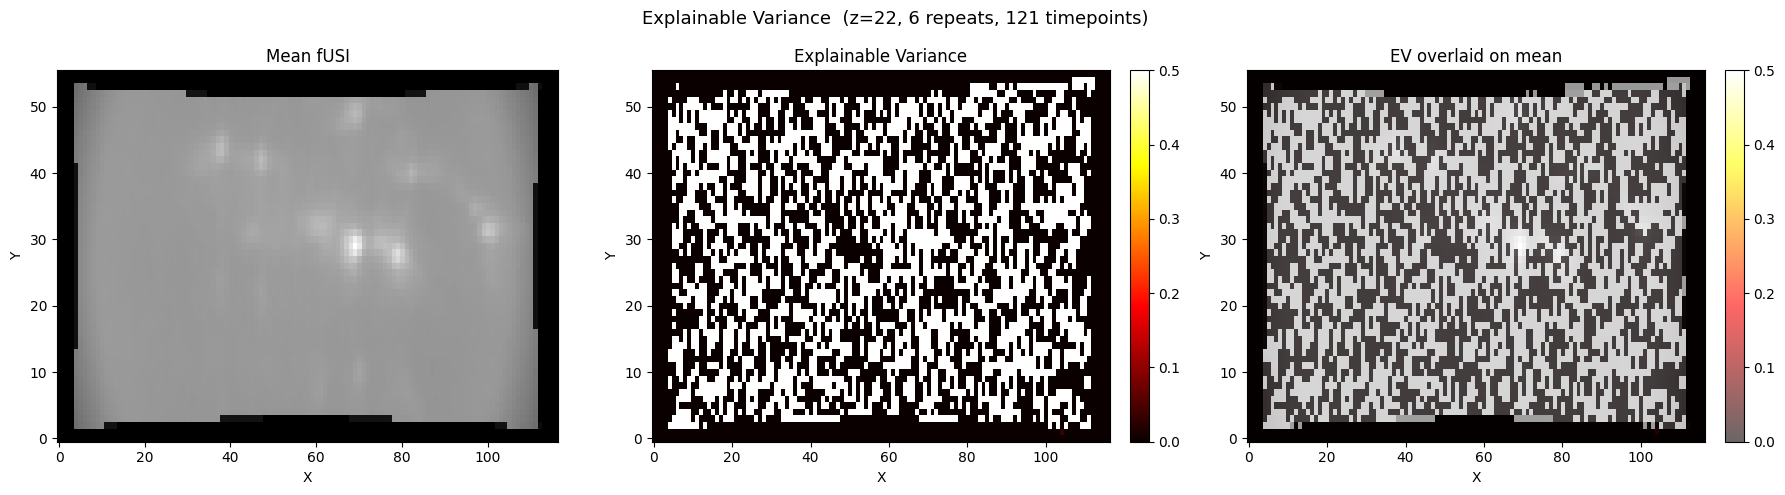

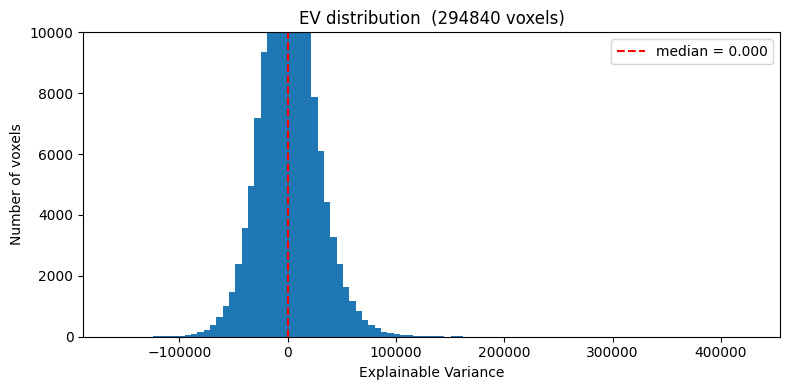

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Explainable Variance – save and plot
# ─────────────────────────────────────────────────────────────────────────────

# Save EV map as NIfTI and numpy
ev_img = nib.Nifti1Image(ev_vol, affine)
ev_img.to_filename(BASE / "explainable_variance_map.nii.gz")
np.save(BASE / "explainable_variance_map.npy", ev_vol)
print(f"Saved: {BASE / 'explainable_variance_map.nii.gz'}")
print(f"Saved: {BASE / 'explainable_variance_map.npy'}")

ev_gallant_img = nib.Nifti1Image(ev_gallant_vol, affine)
ev_gallant_img.to_filename(BASE / "explainable_variance_gallant_map.nii.gz")

# ── Slice views ──────────────────────────────────────────────────────────────
mean_data = nib.load(BASE / "fusi_run_clean_mean.nii.gz").get_fdata()
mid_z = nz // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(mean_data[:, :, mid_z].T, origin='lower', cmap='gray', aspect='auto')
axes[0].set_title("Mean fUSI")

im1 = axes[1].imshow(ev_vol[:, :, mid_z].T, origin='lower', cmap='hot',
                      vmin=0, vmax=0.5, aspect='auto')
axes[1].set_title("Explainable Variance")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(mean_data[:, :, mid_z].T, origin='lower', cmap='gray', aspect='auto')
im2 = axes[2].imshow(ev_vol[:, :, mid_z].T, origin='lower', cmap='hot',
                      alpha=0.6, vmin=0, vmax=0.5, aspect='auto')
axes[2].set_title("EV overlaid on mean")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("X"); ax.set_ylabel("Y")
fig.suptitle(f"Explainable Variance  (z={mid_z}, {N_rep} repeats, "
             f"{time_valid.sum()} timepoints)", fontsize=13)
fig.tight_layout()
fig.savefig(BASE / "explainable_variance_map.png", dpi=300)
plt.show()

# ── Histogram ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ev, bins=100, edgecolor='none')
ax.set_xlabel("Explainable Variance")
ax.set_ylabel("Number of voxels")
ax.set_ylim(0, 10000)
ax.set_title(f"EV distribution  ({n_valid} voxels)")
ax.axvline(np.nanmedian(ev), ls='--', c='r',
           label=f'median = {np.nanmedian(ev):.3f}')
ax.legend()
fig.tight_layout()
fig.savefig(BASE / "explainable_variance_histogram.png", dpi=150)
plt.show()

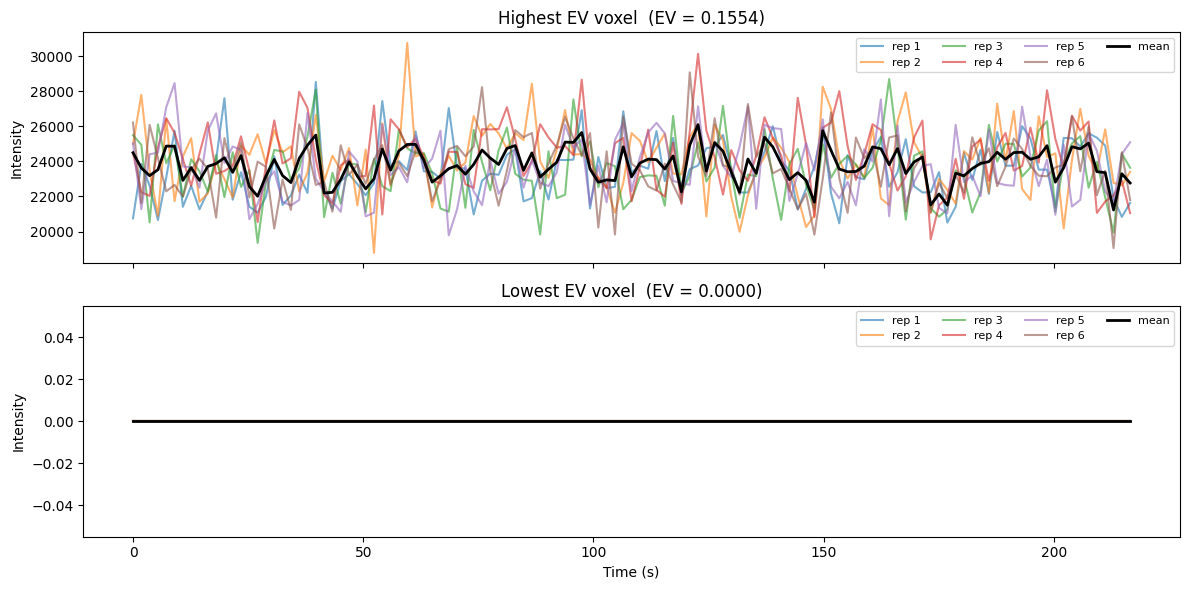

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Overlaid timecourses: highest vs lowest EV voxels
# ─────────────────────────────────────────────────────────────────────────────
# Time axis in seconds (valid timepoints only)
t_sec = np.arange(time_valid.sum()) * TR

# Find best and worst voxels
best_vox = np.argmax(ev)
worst_vox = np.argmin(ev)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# ── Highest EV ───────────────────────────────────────────────────────────────
for rep in range(N_rep):
    axes[0].plot(t_sec, Y_ev[rep, :, best_vox], alpha=0.6, label=f'rep {rep+1}')
axes[0].plot(t_sec, mean_response[:, best_vox], 'k-', lw=2, label='mean')
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"Highest EV voxel  (EV = {ev[best_vox]:.4f})")
axes[0].legend(loc='upper right', ncol=4, fontsize=8)

# ── Lowest EV ────────────────────────────────────────────────────────────────
for rep in range(N_rep):
    axes[1].plot(t_sec, Y_ev[rep, :, worst_vox], alpha=0.6, label=f'rep {rep+1}')
axes[1].plot(t_sec, mean_response[:, worst_vox], 'k-', lw=2, label='mean')
axes[1].set_ylabel("Intensity")
axes[1].set_xlabel("Time (s)")
axes[1].set_title(f"Lowest EV voxel  (EV = {ev[worst_vox]:.4f})")
axes[1].legend(loc='upper right', ncol=4, fontsize=8)

fig.tight_layout()
fig.savefig(BASE / "ev_timecourses_best_worst.png", dpi=150)
plt.show()